In [19]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf

In [24]:
# Load text
with open('Downloads/LP-IV-datasets-20251107T052642Z-1-001/LP-IV-datasets/CBOW(Ass5)/CBOW.txt', 'r', encoding='utf-8') as file:
    text = file.read()

# Split into sentences
sentences = text.split('.')   # or text.split('.') if you prefer

# Clean each sentence
clean_sen = []
for sen in sentences:
    if sen.strip() == "":
        continue
    sen = re.sub('[^A-Za-z0-9]+', ' ', sen)   # remove special chars
    sen = sen.lower().strip()                  # lowercase + trim
    clean_sen.append(sen)

print(clean_sen)


['the speed of transmission is an important point of difference between the two viruses', 'influenza has a shorter median incubation period the time from infection to appearance of symptoms and a shorter serial interval the time between successive cases than covid 19 virus', 'the serial interval for covid 19 virus is estimated to be 5 6 days while for influenza virus the serial interval is 3 days', 'this means that influenza can spread faster than covid 19', 'further transmission in the first 3 5 days of illness or potentially pre symptomatic transmission transmission of the virus before the appearance of symptoms is a major driver of transmission for influenza', 'in contrast while we are learning that there are people who can shed covid 19 virus 24 48 hours prior to symptom onset at present this does not appear to be a major driver of transmission', 'the reproductive number the number of secondary infections generated from one infected individual is understood to be between 2 and 2', 

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [26]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(clean_sen)
seq = tokenizer.texts_to_sequences(clean_sen)
seq

[[1, 37, 2, 3, 9, 38, 39, 40, 2, 41, 13, 1, 42, 22],
 [4,
  43,
  11,
  23,
  44,
  45,
  46,
  1,
  14,
  24,
  47,
  10,
  25,
  2,
  26,
  12,
  11,
  23,
  15,
  16,
  1,
  14,
  13,
  48,
  49,
  17,
  5,
  6,
  7],
 [1,
  15,
  16,
  8,
  5,
  6,
  7,
  9,
  50,
  10,
  18,
  19,
  51,
  20,
  27,
  8,
  4,
  7,
  1,
  15,
  16,
  9,
  28,
  20],
 [29, 52, 30, 4, 31, 53, 54, 17, 5, 6],
 [55,
  3,
  32,
  1,
  56,
  28,
  19,
  20,
  2,
  57,
  58,
  59,
  60,
  61,
  3,
  3,
  2,
  1,
  7,
  62,
  1,
  25,
  2,
  26,
  9,
  11,
  33,
  34,
  2,
  3,
  8,
  4],
 [32,
  63,
  27,
  64,
  21,
  65,
  30,
  66,
  21,
  67,
  68,
  31,
  69,
  5,
  6,
  7,
  70,
  71,
  72,
  73,
  10,
  74,
  75,
  76,
  77,
  29,
  78,
  79,
  80,
  10,
  18,
  11,
  33,
  34,
  2,
  3],
 [1,
  81,
  35,
  1,
  35,
  2,
  82,
  83,
  84,
  24,
  85,
  86,
  87,
  9,
  88,
  10,
  18,
  13,
  36,
  12,
  36],
 [19, 8, 5, 6, 7, 89, 17, 8, 4],
 [90, 91, 8, 92, 5, 6, 12, 4, 22, 21, 93, 94, 12, 14, 95, 9

In [28]:
vocab_size = len(tokenizer.word_index) + 1
emb_size = 10
context_size = 2

contexts = []
targets = []

for sequence in seq:
    for i in range(context_size,len(sequence)-context_size):
        target = sequence[i]
        context = [sequence[i-2],sequence[i-1],sequence[i+1],sequence[i+2]]
        targets.append(target)
        contexts.append(context)

print(contexts)
print(targets)

[[1, 37, 3, 9], [37, 2, 9, 38], [2, 3, 38, 39], [3, 9, 39, 40], [9, 38, 40, 2], [38, 39, 2, 41], [39, 40, 41, 13], [40, 2, 13, 1], [2, 41, 1, 42], [41, 13, 42, 22], [4, 43, 23, 44], [43, 11, 44, 45], [11, 23, 45, 46], [23, 44, 46, 1], [44, 45, 1, 14], [45, 46, 14, 24], [46, 1, 24, 47], [1, 14, 47, 10], [14, 24, 10, 25], [24, 47, 25, 2], [47, 10, 2, 26], [10, 25, 26, 12], [25, 2, 12, 11], [2, 26, 11, 23], [26, 12, 23, 15], [12, 11, 15, 16], [11, 23, 16, 1], [23, 15, 1, 14], [15, 16, 14, 13], [16, 1, 13, 48], [1, 14, 48, 49], [14, 13, 49, 17], [13, 48, 17, 5], [48, 49, 5, 6], [49, 17, 6, 7], [1, 15, 8, 5], [15, 16, 5, 6], [16, 8, 6, 7], [8, 5, 7, 9], [5, 6, 9, 50], [6, 7, 50, 10], [7, 9, 10, 18], [9, 50, 18, 19], [50, 10, 19, 51], [10, 18, 51, 20], [18, 19, 20, 27], [19, 51, 27, 8], [51, 20, 8, 4], [20, 27, 4, 7], [27, 8, 7, 1], [8, 4, 1, 15], [4, 7, 15, 16], [7, 1, 16, 9], [1, 15, 9, 28], [15, 16, 28, 20], [29, 52, 4, 31], [52, 30, 31, 53], [30, 4, 53, 54], [4, 31, 54, 17], [31, 53, 17,

In [29]:
X = np.array(contexts)
Y = np.array(targets)

In [30]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Embedding , Lambda

In [31]:
model = Sequential([
    Embedding(input_dim=vocab_size,output_dim=emb_size,input_length=2*context_size),
    Lambda(lambda x:tf.reduce_mean(x,axis=1)),
    Dense(256,activation='relu'),
    Dense(512,activation='relu'),
    Dense(vocab_size,activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(X,Y,epochs=80)

C:\Users\Devansh\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/80

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0252 - loss: 4.6140   
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0755 - loss: 4.6024 
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0755 - loss: 4.5827
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0818 - loss: 4.5474
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0818 - loss: 4.4932
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0566 - loss: 4.3964
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0503 - loss: 4.2945
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0629 - loss: 4.2137
Epoch 9/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0503 - loss: 4.1887
Epoch 10/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0943 - loss: 4.1403
Epoch 11/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1132 - loss: 4.0761
Epoch 12/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1006 - loss: 4.00

<Axes: >

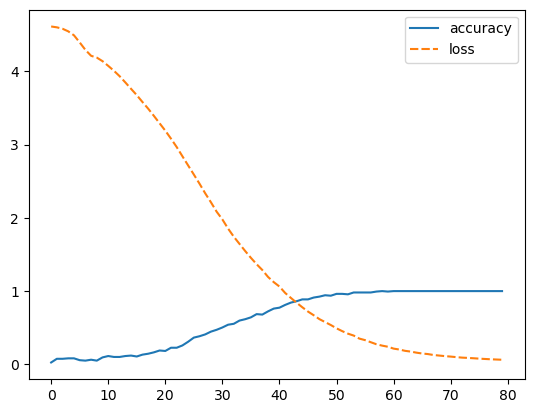

In [32]:
import seaborn as sns
sns.lineplot(model.history.history)

Index to Word mapping:
{1: 'the', 2: 'of', 3: 'transmission', 4: 'influenza', 5: 'covid', 6: '19', 7: 'virus', 8: 'for', 9: 'is', 10: 'to', 11: 'a', 12: 'and', 13: 'between', 14: 'time', 15: 'serial', 16: 'interval', 17: 'than', 18: 'be', 19: '5', 20: 'days', 21: 'are', 22: 'viruses', 23: 'shorter', 24: 'from', 25: 'appearance', 26: 'symptoms', 27: 'while', 28: '3', 29: 'this', 30: 'that', 31: 'can', 32: 'in', 33: 'major', 34: 'driver', 35: 'number', 36: '2', 37: 'speed', 38: 'an', 39: 'important', 40: 'point', 41: 'difference', 42: 'two', 43: 'has', 44: 'median', 45: 'incubation', 46: 'period', 47: 'infection', 48: 'successive', 49: 'cases', 50: 'estimated', 51: '6', 52: 'means', 53: 'spread', 54: 'faster', 55: 'further', 56: 'first', 57: 'illness', 58: 'or', 59: 'potentially', 60: 'pre', 61: 'symptomatic', 62: 'before', 63: 'contrast', 64: 'we', 65: 'learning', 66: 'there', 67: 'people', 68: 'who', 69: 'shed', 70: '24', 71: '48', 72: 'hours', 73: 'prior', 74: 'symptom', 75: 'onset', 

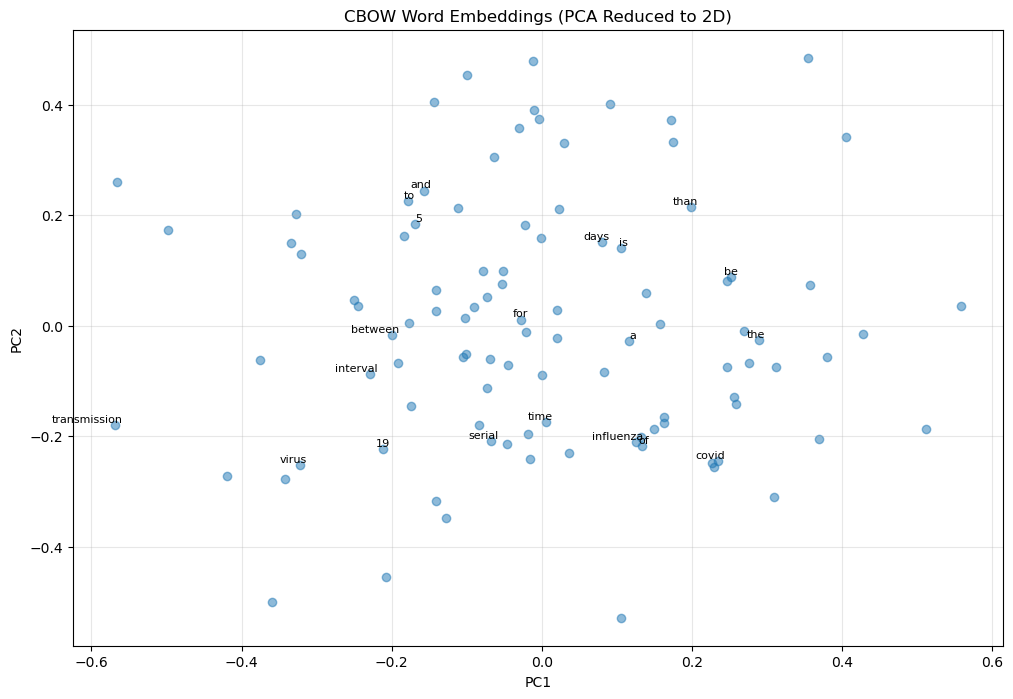

In [39]:
from sklearn.decomposition import PCA
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np

# Get embeddings from the model
embeddings = model.get_weights()[0]

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
reduced_embedding = pca.fit_transform(embeddings)

# Create word-index mappings from tokenizer
index_to_word = {index: word for word, index in tokenizer.word_index.items()}
word_to_index = tokenizer.word_index

print("Index to Word mapping:")
print(index_to_word)
print("\nWord to Index mapping:")
print(word_to_index)

# Test sentences - for CBOW, we need to provide context words to predict center word
test_sentences = [
    "The speed of transmission is an important point of difference between the two",
]

print("\n" + "="*50)
print("TESTING THE MODEL")
print("="*50)

for sent in test_sentences:
    sent_lower = sent.lower()
    test_words = sent_lower.split()
    
    # Convert words to indices
    test_indices = []
    for word in test_words:
        if word in word_to_index:
            test_indices.append(word_to_index[word])
        else:
            print(f"Warning: '{word}' not in vocabulary, skipping")
    
    # For CBOW: predict center word from context
    # We need at least context_size*2 words (2 before + 2 after = 4 context words)
    if len(test_indices) >= (2 * context_size + 1):
        # Take a window of words for prediction
        for i in range(context_size, len(test_indices) - context_size):
            # Get context: 2 words before and 2 words after
            context = [test_indices[i-2], test_indices[i-1], 
                      test_indices[i+1], test_indices[i+2]]
            
            # The actual center word
            actual_word = index_to_word[test_indices[i]]
            
            # Prepare input for model
            x_test = np.array([context])
            
            # Predict
            pred = model.predict(x_test, verbose=0)
            pred_index = np.argmax(pred[0])
            pred_word = index_to_word.get(pred_index, "UNKNOWN")
            
            # Display context and prediction
            context_words = [index_to_word[idx] for idx in context]
            print(f"\nContext: {context_words}")
            print(f"Actual center word: {actual_word}")
            print(f"Predicted word: {pred_word}")
            print(f"Match: {'✓' if pred_word == actual_word else '✗'}")
    else:
        print(f"Sentence too short. Need at least {2*context_size + 1} words.")

# Visualize embeddings
print("\n" + "="*50)
print("VISUALIZING EMBEDDINGS")
print("="*50)

plt.figure(figsize=(12, 8))
plt.scatter(reduced_embedding[:, 0], reduced_embedding[:, 1], alpha=0.5)

# Annotate some words
sample_words = list(word_to_index.keys())[:20]  # Show first 20 words
for word in sample_words:
    if word in word_to_index:
        idx = word_to_index[word]
        plt.annotate(word, 
                    xy=(reduced_embedding[idx, 0], reduced_embedding[idx, 1]),
                    xytext=(5, 2),
                    textcoords='offset points',
                    ha='right',
                    fontsize=8)

plt.title('CBOW Word Embeddings (PCA Reduced to 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()